In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

Libraries loaded successfully!


In [ ]:
# Load Murarka et al. (2021) dataset - combine train, val, test splits
murarka_train = pd.read_csv("datasets/raw/both_train.csv")
murarka_val = pd.read_csv("datasets/raw/both_val.csv")
murarka_test = pd.read_csv("datasets/raw/both_test.csv")


# Combine all Murarka splits
murarka_df = pd.concat([murarka_train, murarka_val, murarka_test], ignore_index=True)
murarka_df.head()

=== Murarka Dataset ===
Train: (13727, 5)
Val: (1488, 5)
Test: (1488, 5)

Combined Murarka: (16703, 5)

Columns: ['ID', 'title', 'post', 'class_name', 'class_id']

First few rows:


,ID,title,post,class_name,class_id
0,691324c4-5c30-44e0-b9e4-45b4f0715e21,a question about the third conditional.,i was making questions for my students and i ran into a little tricky grammar. which is correct ...,none,5
1,d4295391-9ca5-4398-b7c8-687e4a984ef1,the epitome of my life,i've recently requested testing accommodations at my university and was given letters to persona...,adhd,0
2,58937fa5-3c2c-426b-8255-5a140fbab675,what are your favourites offbeat destinations of asia? this is my list.,**cambodia** * koh rong: amazing beaches and a very serene romantic island * kratie: very beauti...,none,5
3,7daf364c-3b33-4cbe-be37-a214edf9a73e,synesthesia survey (what colour is each month to you?),"synesthesia. what is synesthesia? according to google, ""synesthesia is a condition in which one ...",none,5
4,22518271-4bb4-4caf-b683-7305da519288,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",i’m phil baran and i teach organic chemistry at the scripps research institute. i also head the ...,none,5


In [ ]:
print("=== Murarka Label Analysis ===")
print(f"\nUnique class_name values:\n{murarka_df['class_name'].value_counts()}")
print(f"\nUnique class_id values:\n{murarka_df['class_id'].value_counts().sort_index()}")

print(f"\nNull values:\n{murarka_df.isnull().sum()}")

=== Murarka Label Analysis ===

Unique class_name values:
adhd          2961
depression    2946
anxiety       2918
bipolar       2903
ptsd          2497
none          2478
Name: class_name, dtype: int64

Unique class_id values:
0    2961
1    2918
2    2903
3    2946
4    2497
5    2478
Name: class_id, dtype: int64

Null values:
ID            0
title         0
post          0
class_name    0
class_id      0
dtype: int64


In [ ]:
sarkar_df = pd.read_csv("datasets/raw/Combined Data.csv", index_col=0)

print("=== Sarkar Dataset ===")
print(f"Shape: {sarkar_df.shape}")
print(f"\nColumns: {list(sarkar_df.columns)}")
print(f"\nFirst few rows:")
sarkar_df.head()

=== Sarkar Dataset ===
Shape: (53043, 2)

Columns: ['statement', 'status']

First few rows:


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety
3,I've shifted my focus to something else but I'm still worried,Anxiety
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety


In [ ]:
SHARED_LABELS = ['Depression', 'Anxiety', 'Bipolar', 'ADHD', 'PTSD', 'None']

def map_murarka_label(label):
    label_map = {
        'adhd': 'ADHD',
        'anxiety': 'Anxiety',
        'bipolar': 'Bipolar',
        'depression': 'Depression',
        'none': 'None',
        'ptsd': 'PTSD'
    }
    return label_map.get(label.lower(), label)

def map_sarkar_label(label):
    label_map = {
        'Depression': 'Depression',
        'Anxiety': 'Anxiety',
        'Bipolar': 'Bipolar',
        'ADHD': 'ADHD',
        'PTSD': 'PTSD',
        'Normal': 'None',
        'Personality disorder': 'None',  
        'Stress': 'None',  
        'Suicidal': 'Depression'  
    }
    return label_map.get(label, label)


Label mapping functions defined!

Shared schema: ['Depression', 'Anxiety', 'Bipolar', 'ADHD', 'PTSD', 'None']


In [ ]:
murarka_df['text'] = murarka_df['title'].fillna('') + ' ' + murarka_df['post'].fillna('')
murarka_df['text'] = murarka_df['text'].str.strip()

murarka_df['label'] = murarka_df['class_name'].apply(map_murarka_label)
murarka_df['source'] = 'Murarka'

murarka_clean = murarka_df[['text', 'label', 'source']].copy()

murarka_clean.head()

=== Murarka after processing ===
Shape: (16703, 3)

Label distribution:
ADHD          2961
Depression    2946
Anxiety       2918
Bipolar       2903
PTSD          2497
None          2478
Name: label, dtype: int64


,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a ...,None,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,None,Murarka
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,None,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",None,Murarka


In [ ]:
sarkar_df['text'] = sarkar_df['statement'].fillna('').str.strip()

sarkar_df['label'] = sarkar_df['status'].apply(map_sarkar_label)

sarkar_df['source'] = 'Sarkar'

sarkar_clean = sarkar_df[['text', 'label', 'source']].copy()

sarkar_clean.head()

=== Sarkar after processing ===
Shape: (53043, 3)

Label distribution:
Depression              26057
None                    19020
Anxiety                  3888
Bipolar                  2877
Personality disorder     1201
Name: label, dtype: int64


,text,label,source
0,oh my gosh,Anxiety,Sarkar
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety,Sarkar
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety,Sarkar
3,I've shifted my focus to something else but I'm still worried,Anxiety,Sarkar
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety,Sarkar


In [ ]:
combined_df = pd.concat([murarka_clean, sarkar_clean], ignore_index=True)

combined_df = combined_df.dropna(subset=['text', 'label'])

combined_df = combined_df[combined_df['text'].str.strip() != '']

=== Combined Dataset (before cleaning) ===
Shape: (69746, 3)

Null values:
text      0
label     0
source    0
dtype: int64

Empty string counts:
text      362
label       0
source      0
dtype: int64

=== After dropping nulls/empty ===
Shape: (69384, 3)

Null values:
text      0
label     0
source    0
dtype: int64


In [ ]:
duplicates = combined_df['text'].duplicated().sum()

combined_df = combined_df.drop_duplicates(subset=['text'], keep='first')

=== Removing Duplicates ===
Before deduplication: 69384 rows
Exact duplicate posts: 1614
After deduplication: 67770 rows
Removed: 1614 rows


=== Class Balance Analysis ===

Label distribution:
Depression              28674
None                    20808
Anxiety                  6535
Bipolar                  5402
ADHD                     2961
PTSD                     2495
Personality disorder      895
Name: label, dtype: int64

Label percentages:
Depression              42.31
None                    30.70
Anxiety                  9.64
Bipolar                  7.97
ADHD                     4.37
PTSD                     3.68
Personality disorder     1.32
Name: label, dtype: float64

Suggested class weights (for balancing):
{'Depression': 1.0, 'None': 1.3780276816608996, 'Anxiety': 4.387758224942616, 'Bipolar': 5.308034061458719, 'ADHD': 9.683890577507599, 'PTSD': 11.492585170340682, 'Personality disorder': 32.03798882681564}


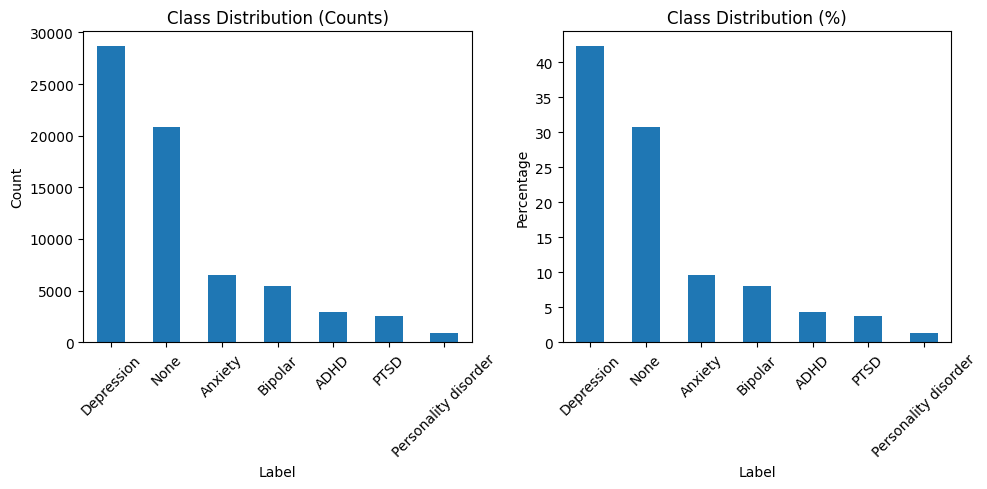

In [ ]:
label_counts = combined_df['label'].value_counts()

label_pct = combined_df['label'].value_counts(normalize=True) * 100

max_count = label_counts.max()
class_weights = {label: max_count / count for label, count in label_counts.items()}

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar')
plt.title('Class Distribution (Counts)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
label_pct.plot(kind='bar')
plt.title('Class Distribution (%)')
plt.xlabel('Label')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
combined_df['word_count'] = combined_df['text'].apply(lambda x: len(str(x).split()))

short_posts = combined_df[combined_df['word_count'] < 5]

p99 = combined_df['word_count'].quantile(0.99)
long_posts = combined_df[combined_df['word_count'] > p99]

=== Word Count Outlier Analysis ===

Word count statistics:
count    67770.000000
mean       136.691368
std        194.637008
min          1.000000
25%         24.000000
50%         81.000000
75%        174.000000
max       6973.000000
Name: word_count, dtype: float64

Posts under 5 words: 2786 (4.11%)
Posts above 99th percentile (>872 words): 678 (1.00%)

=== Examples of short posts (under 5 words) ===
                               text  word_count  source
16703                    oh my gosh           3  Sarkar
16720  restive = restless, restless           4  Sarkar
16735       Terooosss nervous huuuu           3  Sarkar
16740   Feeling so restless lately.           4  Sarkar
16741           Oh god I'm restless           4  Sarkar
16756   Restless.. and.. restless..           3  Sarkar
16759              why am i nervous           4  Sarkar
16763            Very restless bgsd           3  Sarkar
16770      nervous restless peramoy           3  Sarkar
16773              It feels uneas

In [ ]:

combined_df = combined_df[combined_df['word_count'] >= 5]


# Drop the word_count column (was just for analysis)
combined_df = combined_df.drop(columns=['word_count'])


=== Outlier Handling Decision ===
Dropping 2786 posts with < 5 words...
Keeping long posts but documenting 99th percentile: 872 words
Max word count after cleaning: 6973

Final dataset shape: (64984, 3)


In [ ]:
# Save to processed folder
output_path = "datasets/processed/mental_health_cleaned.csv"
combined_df.to_csv(output_path, index=False)

combined_df.sample(5, random_state=42)

=== Final Dataset Summary ===
Shape: (64984, 3)

Columns: ['text', 'label', 'source']

Final label distribution:
Depression              28565
None                    18214
Anxiety                  6453
Bipolar                  5401
ADHD                     2961
PTSD                     2495
Personality disorder      895
Name: label, dtype: int64

Source distribution:
Sarkar     48287
Murarka    16697
Name: source, dtype: int64

✅ Saved cleaned dataset to: datasets/processed/mental_health_cleaned.csv

=== Sample of final dataset ===


,text,label,source
56353,i ve had this thought for several year now and i can t break out of my thought i hope you guy wo...,Depression,Sarkar
37234,My life is going nowhere. I lost half the money I had been saving up over the past year from my ...,Depression,Sarkar
6203,megathread: president trump pardons former sheriff joe arpaio president trump pardoned former ar...,None,Murarka
20974,But it's good that the A&W Ipoh Parade is open.,None,Sarkar
44630,"She still invites me to things and hasn't started dating anyone else (or even talked about it), ...",None,Sarkar
